# Week 5 - Bivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns

# 1. Lesson: Bivariate graphs

In this lesson, we'll consider some bivariate plots: scatter plots, line plots, waterfall plots, area plots, and pair plots.  We'll also look at bivariate statistics such as correlations, ratios, and percentages.  First, let's create some data.

In [2]:
np.random.seed(0)
numpoints = 100
lesson_series_uniform = np.round(np.random.random(size = numpoints) * 100, 2)
lesson_series_base = np.round(np.random.random(size = numpoints)**2 * 100, 2)
lesson_series_skewed = lesson_series_base + np.random.normal(scale = 10, size = numpoints)
lesson_series_reverse = 100 - lesson_series_base + np.random.normal(scale = 10, size = numpoints)

This scatter plot puts one series against another.  The two series are anticorrelated - one goes up when the other goes down.

<Axes: >

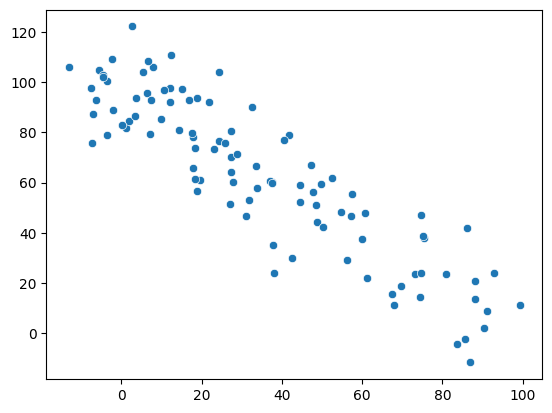

In [3]:
sns.scatterplot(x = lesson_series_skewed, y = lesson_series_reverse)

This pair plot compares three series against one another.  The diagonal shows the histogram of each series, while the non-diagonal entries plot two different series against each other.  The result in column 1, row 2 is a scatter plot that compares series #1 with series #2.  In effect, when the logic of the pair plot tells us to plot a series against itself (column 1, row 1), we draw a histogram.  (It would be silly to draw a scatter plot of a series against itself).  Because series #1 is not based on the "base" series, it is not correlated with series #2 or series #3, so the four scatter plots that compare series #1 to #2 and #3 look patternless.  The two scatter plots that compare series #2 with series #3 do appear to be correlated due to the "base" series that they share in common.

In [4]:
df = pd.DataFrame(np.array([lesson_series_uniform, lesson_series_skewed, lesson_series_reverse]).T, columns = ['uniform', 'skewed', 'reverse'])

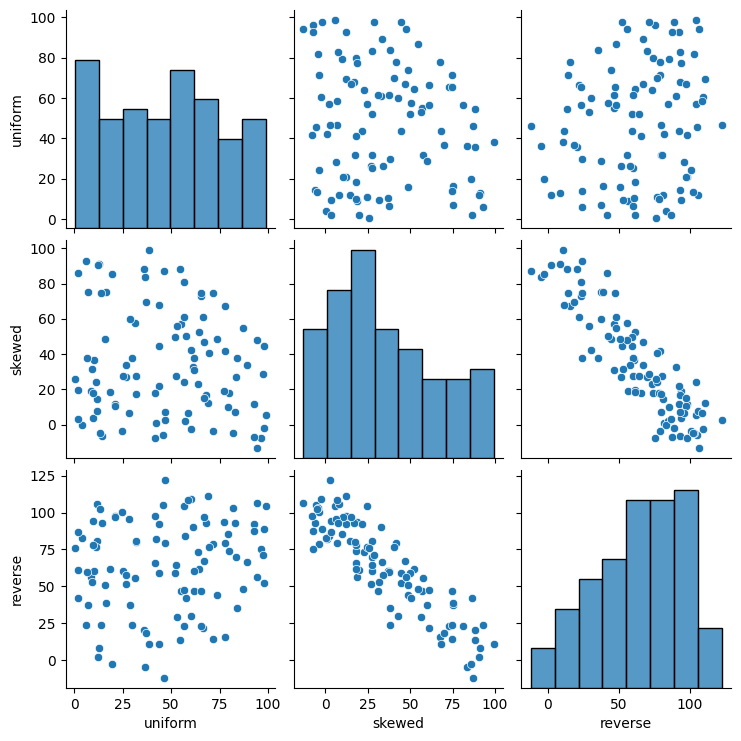

In [5]:
sns.pairplot(df)

We can compute the correlation coefficience between each pair.

In [6]:
print("Correlations:", df.corr())

Correlations:           uniform    skewed   reverse
uniform  1.000000 -0.145022  0.149771
skewed  -0.145022  1.000000 -0.894549
reverse  0.149771 -0.894549  1.000000


This shows that there is a strong negative correlation between the "skewed" and "reverse" datasets (a larger negative number in row 2, column 3 and in row 3, column 2) and almost no correlation between the "uniform" dataset and the others (the much smaller numbers at those locations in the table.)

Q: What is a correlation telling us?

If the correlation is large (close to 1) it tells us that the two variables are usually either both large or both small in value.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the lower left to upper right.

If the correlation is very negative (close to -1), it tells us that when one variable is large, the other is small.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the upper left to lower right.

If the correlation is zero, it tells us that the two variables, plotted on a scatter plot, would form a cloud.  The cloud can have different shape - for instance, it could be square or circular - but it cannot look like a diagonal line.  Knowing the value of one variable would tell you nothing about the value of the other variable.  (At least, it would not tell you whether the other variable is large or small).

The correlation coefficients above are called by the letter R.  R can be positive or negative, and lies between -1 and 1.  If we square R, we get a value called $R^2$ which is sometimes used to describe the correlation.  Unless R = 0 or 1, $R^2$ will be smaller in magnitude than R (and always positive), which means that it is very important to know if you are talking about R or $R^2$.  Since the values above can be negative, you can know for sure that they are R values, not $R^2$.

Q: How do you decide if a correlation is strong?

It depends on the application.  Some sources say that a correlation of R = 0.7 or 0.8 is strong, but in other applications (say, the social sciences) a correlation of 0.5 might be considered quite strong.  It is not unusual for social scientists to report correlations even as low a 0.2 as being important.

Q: What is the purpose of finding a correlation?

Here are a few:

1. Variables that are correlated with a target variable might be especially useful in predicting that variable.  This might also suggest that a linear model could work.  On the other hand, just because there are no pairwise correlations doesn't mean that a linear model won't work.  For example, if you select X, Y, and Z from this list of four possibilities: \[\[X = 1, Y = 0, Z = 0], \[X = 0, Y = 1, Z = 0], \[X = 0, Y = 0, Z = 1], \[X = 1, Y = 1, Z = 1]] then any two variables are completely uncorrelated, but the sum of the three is usually 1.  So the linear model Z = 1 - X - Y is accurate in three out of four cases even though all pairwise correlations are zero.

2. Variables that are very correlated with each other might be redundant.  In the extreme case, two variables that have a correlation of 1.0 are "linearly dependent" - they essentially provide the same information.  For example, if one column is a height in inches, and another is a height in centimeters, then they are redundant.  Moreover, if you use two highly correlated variables as predictors, the results will be somewhat unpredictable.  For example, if HI is the height in inches and HC is the height in centimeters, then the following formulas are all equivalent: HC, 2.54 * HI, 0.5 * HC + 1.27 * HI, 1001 * HC - 2540 * HI.  So there's no knowing which one you'll get if you try to build a model based on these variables.  The last one in particular is a little bit surprising, given the large coefficients, but it could very well be the result of a linear regression analysis.

3. Correlation can help you to detect problems with the data.  If two variables are correlated but shouldn't be, or if they're not correlated but should be, there might be something wrong with the data.  It's important to test the data to see if it makes sense.

4. Correlations can be interesting things to report.  If your client or organization is asking for a verbal explanation of the dataset, they might be interested in knowing about any correlations for reasons of their own.

A waterfall chart shows a value after a sequence of inputs and outputs.

In [7]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name='This title is not displayed',
    orientation='v',
    measure=['absolute','relative','relative','relative','relative'],
    x=["2023-Jan", "receipts-in", "interest-in", "expenses-out", "interest-out", "2024-Jan"],
    textposition='outside',
    text=['Total','after-receipts','after-interest','after-expenses','after-interest'],
    y=[123.45,42.08,21.97,-54.31,-50.23],
    connector=dict(line=dict(color='rgb(63, 63, 63)'))
))

fig.update_layout(
    title='Waterfall Plot',
    showlegend=False
)
fig.update_yaxes(range=[-1,230])
fig.show()

A line plot is typically associated with a time or date range.  It shows how a variable rises and falls over a period of time.

/tmp/ipykernel_20234/2082488306.py:3: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



<Axes: xlabel='None'>

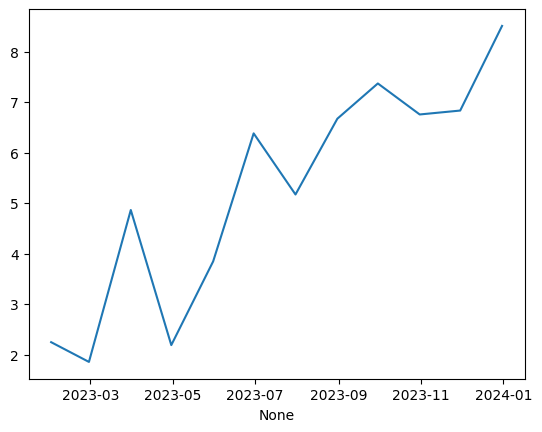

In [8]:
numdates = 12
time_series = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
sns.lineplot(x = datearray, y = time_series)

An area plot stacks one curve on top of another.  In the graph below, the top line shows the sum of the two series (ser1 + ser2) while the bottom line just shows ser1.

<Axes: >

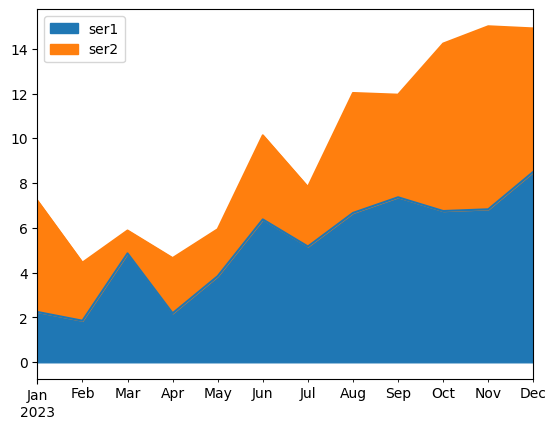

In [9]:
time_series_2 = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 2. Weekly graph question

Below is a pair plot showing the correlation between the levels of chemical A, B, and C in a water sample.  If you had to choose just _three_ of the nine graphs in the pair plot to display, which would you choose?  How would you alter the way these graphs are displayed to make them clearer or more informative?  Would you fit any of these graphs to a line or curve?  Why or why not?  What if you had to choose just _one_?  What if you had to choose _six_?

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)
num_data = 100
base_data = np.random.random(size = num_data)
chem1 = base_data + np.random.normal(size = num_data) * 0.1
chem2 = base_data**2 + np.random.normal(size = num_data) * 0.1
chem3 = 1 - base_data + np.random.normal(size = num_data) * 0.1
df_chem = pd.DataFrame({'chem1':chem1,'chem2':chem2,'chem3':chem3})

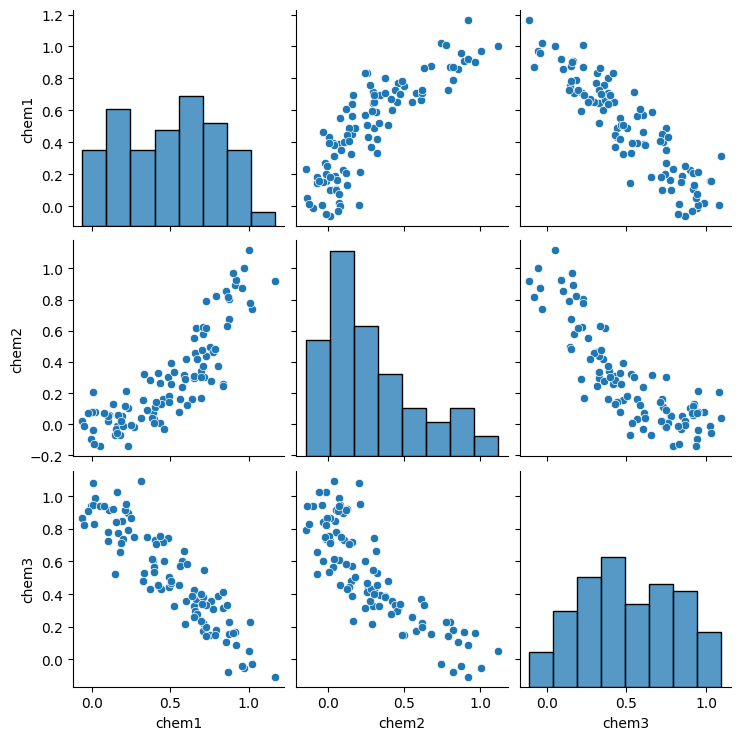

In [11]:
sns.pairplot(df_chem)

Understanding what the pair plot contains:
The 3×3 grid has nine panels. Three are on the diagonal — histograms of each single chemical's distribution, showing no relationship between variables. Three are in the lower triangle and three in the upper triangle — but each upper panel is an exact mirror of the corresponding lower panel with axes swapped. So the nine panels contain only three genuinely distinct pieces of information: the pairwise relationship between each pair of chemicals.
Understanding the data generation code reveals exactly what those relationships are:

chem1 ≈ base_data — roughly uniform
chem2 ≈ base_data² — so chem2 = chem1² → positive quadratic
chem3 ≈ 1 − base_data — so chem3 = 1 − chem1 → strong negative linear

If you had to choose three:
The three lower-triangle scatter plots: chem1 vs chem3, chem1 vs chem2, chem2 vs chem3. These are the only panels that show non-redundant information. The three upper-triangle panels are exact mirrors and can be discarded; the three diagonal histograms describe individual distributions but not relationships between chemicals.
Formatting improvements:

Add a descriptive action title to each panel stating the relationship, not just variable names
Add a fitted curve with the equation and R² annotated directly on the chart
Remove the heavy default border and darken the dots slightly — seaborn's default pale blue makes patterns harder to see
Use consistent axis ranges across all three panels so the reader can compare scales directly

Fit a line or curve?:
Yes, and the choice of line vs curve matters here:
chem1 vs chem3 — fit a straight line (R² = 0.83). The relationship is chem3 = 1 − chem1, which is perfectly linear. A quadratic fit would overfit the data with no benefit.
chem1 vs chem2 — fit a quadratic curve (R² = 0.79). The relationship is chem2 = chem1², which is clearly curved — the dots fan upward at both ends. Fitting a straight line would be misleading because it would suggest an intercept below zero when none exists.
chem2 vs chem3 — also fit a quadratic curve (R² = 0.72). Since chem2 and chem3 are both derived from the same underlying base variable, their relationship is chem3 ≈ 1 − √chem2, which is a decreasing curved relationship. The curve fits noticeably better than a line for the points below chem2 = 0.3.

If you had to choose just one:
chem1 vs chem3 — the strongest relationship (r = −0.91, R² = 0.83) and the cleanest story: as Chemical A increases, Chemical C decreases by almost exactly the same amount. This is the most linear, most tightly clustered, and most immediately legible of the three scatter plots. It is also the most actionable for a water quality analyst — a near-perfect inverse relationship between two chemicals suggests they may be chemically linked (e.g., one is being converted into another, or they share a common precursor).

If you had to choose six:
Add the three diagonal histograms back alongside the three scatter plots, but improve their usefulness by adding a KDE overlay to smooth the distribution shape. Replace the three redundant upper-triangle mirrors with large correlation coefficient text (r = value) on a shaded background. This is the approach used in the best-six figure above:

Lower triangle (3 panels): scatter plots with fitted lines/curves and R² annotations
Diagonal (3 panels): histograms with KDE overlay showing each chemical's distribution shape
Upper triangle (3 panels): large bold r value on a tinted background for instant scanning

This layout gives the reader everything — distribution shape of each variable, the exact strength of each pairwise correlation, and the visual shape of each relationship — without any redundant panels. The upper-triangle correlation summary lets someone scan the relationship strengths in under two seconds without reading any of the scatter plots, which is the practical first question a water quality analyst would ask.

# 3. Homework - Reproducing Pair Plot Graphs

I'm going to show you some Pair Plot (Scatter and Histogram) graphs.  I'd like you to generate some data that will generate those graphs.

Example: this cloud involves a match between two normal distributions.

<Axes: xlabel='data1', ylabel='data2'>

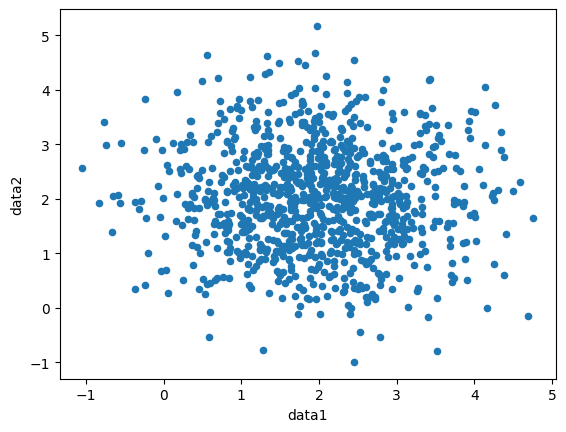

In [12]:
num_points = 1000
np.random.seed(0)
data1 = np.random.normal(size = num_points) + 2
data2 = np.random.normal(size = num_points) + 2
df_twonorm = pd.DataFrame({"data1":data1,"data2":data2})
df_twonorm.plot.scatter(x = "data1", y = "data2")

Problem: Can you design data that will generate the following scatter plot?  You may need to join multiple series to make one big series for the y-axis data.  That will allow you to create the two clouds. Use Google or ChatGPT to find the function that does that.  It is okay if the precise numbers are not re-created; just the general shape: two vertically separated clouds of points.

In [13]:
from IPython.display import Image
Image("twoclouds.png")

FileNotFoundError: No such file or directory: 'twoclouds.png'

FileNotFoundError: No such file or directory: 'twoclouds.png'

<IPython.core.display.Image object>

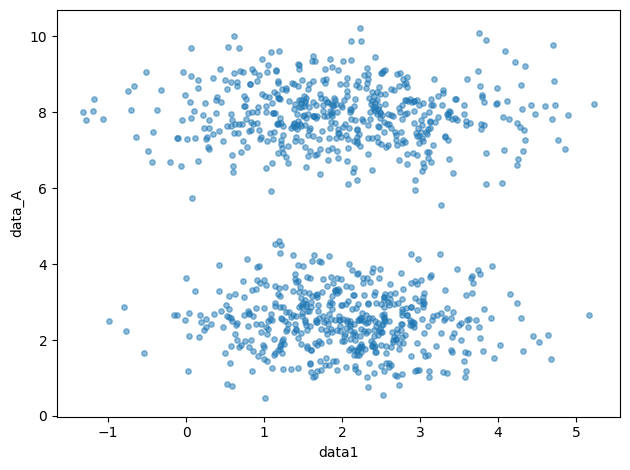

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
n = 500   # points per cloud

# ── Upper cloud: x centred ~2, y centred ~8 ──────────────────────────────────
x_upper = np.random.normal(loc=2.0, scale=1.2, size=n)
y_upper = np.random.normal(loc=8.0, scale=0.8, size=n)

# ── Lower cloud: x centred ~2, y centred ~2.5 ────────────────────────────────
x_lower = np.random.normal(loc=2.0, scale=1.0, size=n)
y_lower = np.random.normal(loc=2.5, scale=0.8, size=n)

# ── Join both clouds into single series using np.concatenate() ───────────────
data1  = np.concatenate([x_upper, x_lower])   # combined x
data_A = np.concatenate([y_upper, y_lower])   # combined y

df = pd.DataFrame({'data1': data1, 'data_A': data_A})

# ── Plot ──────────────────────────────────────────────────────────────────────
df.plot.scatter(x='data1', y='data_A', alpha=0.5, s=15)
plt.tight_layout()
plt.show()

Challenge problem!  Hint: you will need two series, and three segments of the first series will connect with the three segments of the second series.

In [15]:
from IPython.display import Image
Image("threeclouds.png")

FileNotFoundError: No such file or directory: 'threeclouds.png'

FileNotFoundError: No such file or directory: 'threeclouds.png'

<IPython.core.display.Image object>

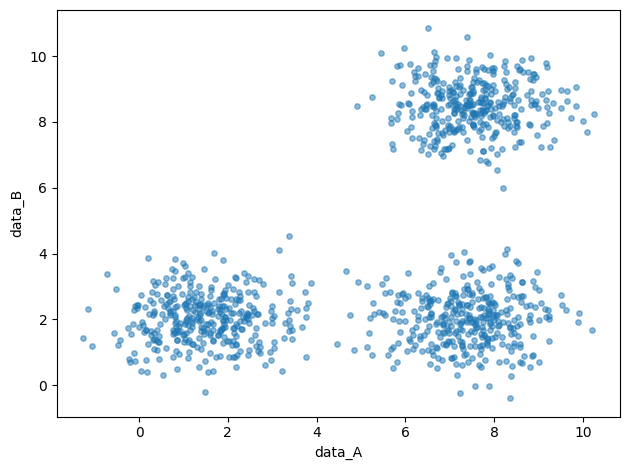

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
n = 350   # points per cloud

# ── Three x-axis segments (data_A) ───────────────────────────────────────────
x1 = np.random.normal(loc=1.5, scale=1.0, size=n)   # bottom-left cloud
x2 = np.random.normal(loc=7.5, scale=1.0, size=n)   # bottom-right cloud
x3 = np.random.normal(loc=7.5, scale=1.0, size=n)   # top-right cloud

# ── Three y-axis segments (data_B) ───────────────────────────────────────────
y1 = np.random.normal(loc=2.0, scale=0.8, size=n)   # bottom-left cloud
y2 = np.random.normal(loc=2.0, scale=0.8, size=n)   # bottom-right cloud
y3 = np.random.normal(loc=8.5, scale=0.8, size=n)   # top-right cloud

# ── Join the three segments of each series with np.concatenate() ─────────────
data_A = np.concatenate([x1, x2, x3])
data_B = np.concatenate([y1, y2, y3])

df = pd.DataFrame({'data_A': data_A, 'data_B': data_B})

# ── Plot ──────────────────────────────────────────────────────────────────────
df.plot.scatter(x='data_A', y='data_B', alpha=0.5, s=15)
plt.tight_layout()
plt.show()

Why this works:

The challenge is that x2 and x3 both have the same centre (x ≈ 7.5) but need different y-values — one cloud sits low (y ≈ 2) and one sits high (y ≈ 8.5). The only way to achieve this is to generate two completely independent x segments at the same location and pair each one with its own y segment. A single np.random.normal() call for x cannot know that some of those x-values should land high and others low — the pairing must be established by position in the concatenated array. This is exactly what the hint means by "three segments of the first series will connect with the three segments of the second series."

Would you expect to see a correlation for this challenge problem?  (Hint: does knowing the value of data_A tell you anything about the value of data_B - in particular, whether it is large or small?)  If you managed to reproduce the graph using data, test it yourself using the corr() function.

In [17]:
df.corr()

,data_A,data_B
data_A,1.000000,0.472852
data_B,0.472852,1.000000


Would you expect a correlation?

Partially — and for an interesting reason. The answer depends on whether you look at the data globally or within each cloud.

Within any single cloud, there is no correlation. Each cloud was generated with independent x and y draws from np.random.normal(), so knowing where a point sits horizontally within a cloud tells you nothing about its vertical position. The within-cloud correlations confirm this: r ≈ 0.06, 0.02, and −0.007 — essentially zero for all three.
Across the whole dataset, however, there is a moderate positive correlation — df.corr() gives r = 0.47.

So a low value of data_A is a reliable predictor that data_B will be low, but a high value of data_A is ambiguous — it could pair with either a low or a high data_B. This asymmetry is enough to produce a moderate positive r, even though there is no genuine linear relationship in the data.

The key lesson:

This is a classic example of why correlation does not fully describe a relationship and why you should always visualise your data alongside any summary statistic. An r of 0.47 might lead you to conclude there is a moderate upward trend between the two chemicals, when in reality the data contains three discrete clusters with no trend whatsoever inside any of them. The correlation here is an artefact of the cluster positions, not evidence of a genuine linear relationship. This is related to Simpson's Paradox — a statistic computed over a mixed population can be misleading when the population contains distinct subgroups.

Here is a histogram.  Can you provide data that will approximately re-create this histogram?

It is okay if the precise numbers are not re-created; just the general shape: tailing off on either side, but tailing off to a nonzero number.  (In this case, about 300).

<Axes: ylabel='Frequency'>

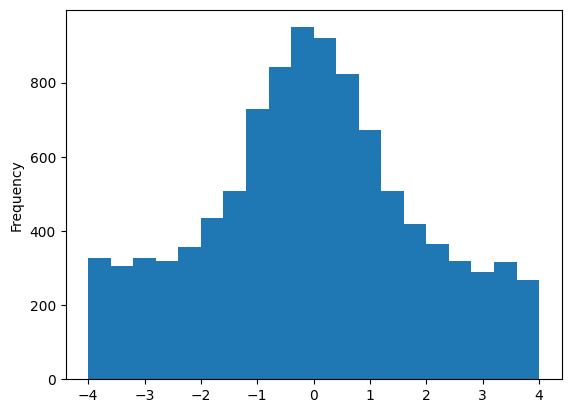

In [18]:
np.random.seed(0)

# Component 1: normal — creates the bell shape
normal_part  = np.random.normal(loc=0, scale=1.0, size=4000)

# Component 2: uniform — creates the non-zero floor
uniform_part = np.random.uniform(low=-4, high=4, size=6000)

# Join the two series with np.concatenate()
arr = np.concatenate([normal_part, uniform_part])

# Plot
pd.Series(arr, name='arr').plot.hist(bins=20)

Why np.concatenate() again:

Just like the two-cloud and three-cloud problems, the trick is generating two independent components and joining them with np.concatenate(). A plain np.random.normal() alone would produce tails that fall smoothly to zero — it cannot produce the flat floor on its own. Mixing in a uniform distribution is what prevents the tails from reaching zero, because the uniform contributes the same number of points to every bin across the entire range.

In [19]:
from IPython.display import Image
Image("histogram.png")

FileNotFoundError: No such file or directory: 'histogram.png'

FileNotFoundError: No such file or directory: 'histogram.png'

<IPython.core.display.Image object>

Create a line plot that shows a sales volume of soft drinks that decreases, then increases over the course of a year, in a U-shaped curve, but with some noise.

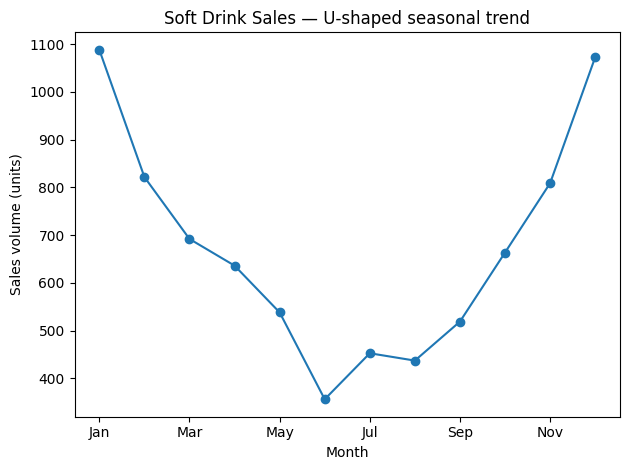

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

months     = np.arange(1, 13)
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# U-shaped base: quadratic with trough in mid-year
# Peak ~1000 units (Jan/Dec), trough ~400 units (Jun/Jul)
a           = 600 / (1 - 6.5)**2        # coefficient so ends reach ~1000
sales_clean = a * (months - 6.5)**2 + 400

# Add noise (~50 units std)
noise = np.random.normal(loc=0, scale=50, size=12)
sales = sales_clean + noise

# Build DataFrame and plot
df = pd.DataFrame({'month': month_names, 'sales': sales})
df.plot.line(x='month', y='sales', marker='o', legend=False)

plt.title('Soft Drink Sales — U-shaped seasonal trend')
plt.xlabel('Month')
plt.ylabel('Sales volume (units)')
plt.tight_layout()
plt.show()

Create an area plot that shows the sales volume for two brands of soft drinks, one of which is increasing then decreasing, the other decreasing then increasing.

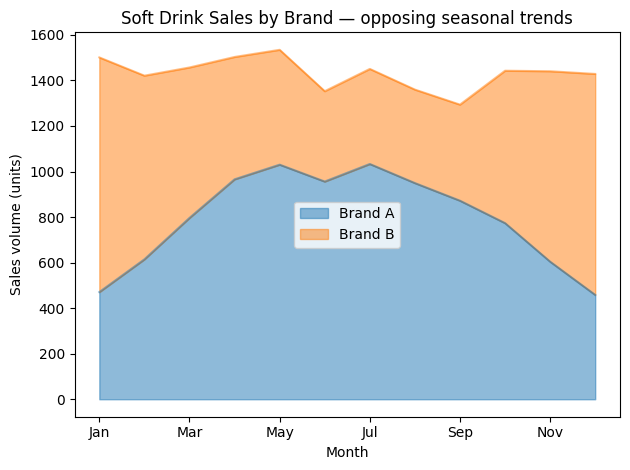

In [21]:
np.random.seed(0)

months      = np.arange(1, 13)
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Shared coefficient — sets how steeply each curve rises/falls
a = 600 / (1 - 6.5)**2

# Brand A: arch shape — increases then decreases (peak mid-year ~1000)
brand_A = -a * (months - 6.5)**2 + 1000 + np.random.normal(0, 40, 12)

# Brand B: U shape — decreases then increases (trough mid-year ~400)
brand_B =  a * (months - 6.5)**2 + 400  + np.random.normal(0, 40, 12)

# Build DataFrame and plot
df = pd.DataFrame({
    'Brand A': brand_A,
    'Brand B': brand_B
}, index=month_names)

df.plot.area(alpha=0.5)

plt.title('Soft Drink Sales by Brand — opposing seasonal trends')
plt.xlabel('Month')
plt.ylabel('Sales volume (units)')
plt.tight_layout()
plt.show()

The approach

Brand A — increases then decreases → an inverted U (arch): −a*(month − 6.5)² + peak
Brand B — decreases then increases → a U-shape: +a*(month − 6.5)² + trough

The two shapes are mathematical opposites of each other — simply negating the quadratic coefficient flips the arch into the U. Both are given the same scale so the area plot shows them as comparably sized regions that cross each other mid-year.

Why an area plot?:

An area plot fills the region between the line and the x-axis with colour, making it easy to compare the total volume of two series simultaneously. When both brands are plotted together with alpha=0.5 (semi-transparent), the overlap region is visible as a blended colour, clearly showing which brand dominates at each point in the year and where they cross.

# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 71-85 of the Storytelling With Data book as best you can.  (The first half of chapter three).

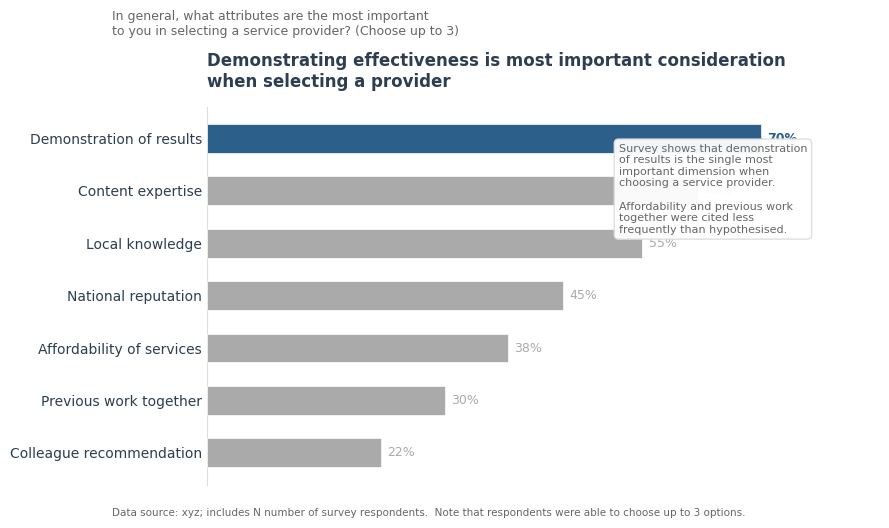

In [22]:
import matplotlib.pyplot as plt

# ── Data from SWD Figure 3.14 (p.82) ─────────────────────────────────────────
# Survey: "What attributes are most important in selecting a service provider?"
# Respondents chose up to 3 options

attributes = [
    'Colleague recommendation',
    'Previous work together',
    'Affordability of services',
    'National reputation',
    'Local knowledge',
    'Content expertise',
    'Demonstration of results',   # highest — the story
]
values = [22, 30, 38, 45, 55, 62, 70]

# ── Colours: highlight top bar (the insight), grey the rest ──────────────────
HIGHLIGHT = '#2C5F8A'
GREY      = '#AAAAAA'
DARK      = '#2C3E50'
TEXT_GREY = '#666666'

bar_colors = [GREY] * (len(attributes) - 1) + [HIGHLIGHT]

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Horizontal bar chart ──────────────────────────────────────────────────────
bars = ax.barh(attributes, values,
               color=bar_colors, height=0.55,
               edgecolor='white', linewidth=0.5, zorder=3)

# ── Direct % labels on each bar ───────────────────────────────────────────────
for bar, val in zip(bars, values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val}%',
            va='center', ha='left', fontsize=9,
            color=HIGHLIGHT if val == 70 else GREY,
            fontweight='bold' if val == 70 else 'normal')

# ── SWD Clutter elimination ───────────────────────────────────────────────────
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)   # removed — bars are directly labelled
ax.spines['left'].set_color('#DDDDDD')

ax.set_xticks([])                        # no x-axis ticks needed
ax.tick_params(axis='y', length=0, labelsize=10, colors=DARK)
ax.set_xlim(0, 85)

# ── Action title ──────────────────────────────────────────────────────────────
ax.set_title(
    'Demonstrating effectiveness is most important consideration\n'
    'when selecting a provider',
    fontsize=12, fontweight='bold', color=DARK, loc='left', pad=14
)

# ── Survey question as subtitle ───────────────────────────────────────────────
fig.text(0.13, 0.93,
    'In general, what attributes are the most important\n'
    'to you in selecting a service provider? (Choose up to 3)',
    fontsize=9, color=TEXT_GREY, va='top')

# ── Insight annotation ────────────────────────────────────────────────────────
ax.annotate(
    'Survey shows that demonstration\nof results is the single most\n'
    'important dimension when\nchoosing a service provider.\n\n'
    'Affordability and previous work\ntogether were cited less\n'
    'frequently than hypothesised.',
    xy=(70, 6), xytext=(52, 4.2),
    fontsize=8, color=TEXT_GREY,
    arrowprops=dict(arrowstyle='->', color=HIGHLIGHT, lw=1.1),
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#DDDDDD', alpha=0.95)
)

# ── Data source footnote ──────────────────────────────────────────────────────
fig.text(0.13, 0.01,
    'Data source: xyz; includes N number of survey respondents.  '
    'Note that respondents were able to choose up to 3 options.',
    fontsize=7.5, color=TEXT_GREY)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.show()